# KNN : K-nearest neighbors

Euclidean Distance=[(f11-f22)^2+(f21-f22)^2]^1/2

In [1]:
import pandas as pd
df=pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
x=df.iloc[:,0:8]
y=df['Outcome']
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [3]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)
print(x_test)
print(y_test)

(614, 8)
(614,)
(154, 8)
(154,)
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
285            7      136             74             26      135  26.0   
101            1      151             60              0        0  26.1   
581            6      109             60             27        0  25.0   
352            3       61             82             28        0  34.4   
726            1      116             78             29      180  36.1   
..           ...      ...            ...            ...      ...   ...   
563            6       99             60             19       54  26.9   
318            3      115             66             39      140  38.1   
154            8      188             78              0        0  47.9   
684            5      136             82              0        0   0.0   
643            4       90              0              0        0  28.0   

     DiabetesPedigreeFunction  Age  
285                     0.647   51  
101  

In [4]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=15)
model=nn.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [5]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=15)
model.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [6]:
diff=pd.DataFrame({'Actual':y_test,'predicted':prediction})
diff

,Actual,predicted
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


In [7]:
diff.to_excel('diabetes_data.xlsx')

In [8]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[89 10]
 [23 32]]


- [[TN FP] [FN TP]]

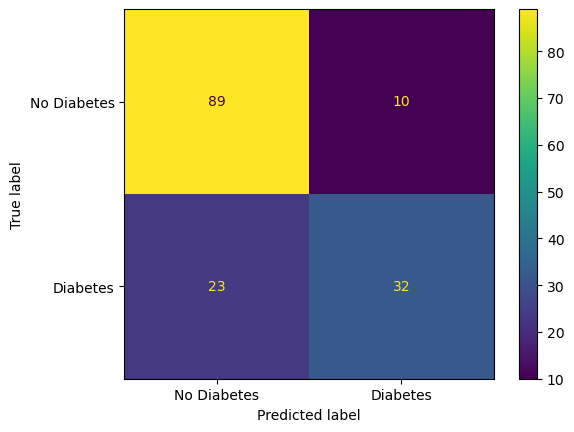

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['No Diabetes','Diabetes'])
cm_display.plot()
plt.show()

In [10]:
cm

array([[89, 10],
       [23, 32]])

In [12]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print("TN:",TN)
print("FP:",FP)
print("FN:",FN)
print("TP:",TP)

TN: 89
FP: 10
FN: 23
TP: 32


In [18]:
accuracy=(TN+TP)/(TN+FP+FN+TP)
print("Accuracy Score:",accuracy)

Accuracy Score: 0.7857142857142857


In [19]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y_test,prediction))

Accuracy Score: 0.7857142857142857


In [20]:
error_rate=(FP+FN)/(TN+FP+FN+TP)
print("Error Rate:",error_rate)

Error Rate: 0.21428571428571427


In [22]:
from sklearn.metrics import accuracy_score
print("Error Rate:",1-accuracy_score(y_test,prediction))

Error Rate: 0.2142857142857143


In [23]:
sensitivity=TP/(TP+FN)
print(sensitivity)

0.5818181818181818


In [24]:
specificity=TN/(TN+FP)
print(specificity)

0.898989898989899


In [26]:
from sklearn.metrics import recall_score
print("Sensitivity:",recall_score(y_test,prediction))
print("Specificity:",recall_score(y_test,prediction,pos_label=0))

Sensitivity: 0.5818181818181818
Specificity: 0.898989898989899


In [27]:
from sklearn.metrics import recall_score
print("Sensitivity:",recall_score(y_test,prediction,pos_label=1))   #pos_label=1 default value
print("Specificity:",recall_score(y_test,prediction,pos_label=0))

Sensitivity: 0.5818181818181818
Specificity: 0.898989898989899


In [28]:
precision_score=TP/(TP+FP)
print("Precision Score:",precision_score)

Precision Score: 0.7619047619047619


In [29]:
from sklearn.metrics import precision_score
print("Precision Score(for positive):",precision_score(y_test,prediction))


Precision Score(for positive): 0.7619047619047619


In [30]:
from sklearn.metrics import precision_score
print("Precision Score(for Negative):",precision_score(y_test,prediction,pos_label=0))

Precision Score(for Negative): 0.7946428571428571


In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
accuracy=[]
for i in range(1,31):
    nn=KNeighborsClassifier(n_neighbors=i)
    model=nn.fit(x_train,y_train)
    prediction=model.predict(x_test)
    accuracy.append(accuracy_score(y_test,prediction))
accuracy    


[0.7207792207792207,
 0.7272727272727273,
 0.7402597402597403,
 0.7207792207792207,
 0.7337662337662337,
 0.7727272727272727,
 0.7597402597402597,
 0.7662337662337663,
 0.7662337662337663,
 0.7597402597402597,
 0.7467532467532467,
 0.7727272727272727,
 0.7662337662337663,
 0.7727272727272727,
 0.7857142857142857,
 0.7857142857142857,
 0.7857142857142857,
 0.7727272727272727,
 0.7727272727272727,
 0.7727272727272727,
 0.7662337662337663,
 0.7727272727272727,
 0.7662337662337663,
 0.7792207792207793,
 0.7532467532467533,
 0.7727272727272727,
 0.7532467532467533,
 0.7662337662337663,
 0.7662337662337663,
 0.7792207792207793]

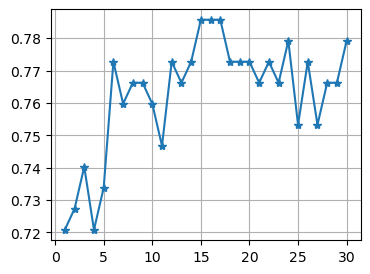

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.plot(range(1,31),accuracy,marker="*")
plt.grid(True)
plt.show()

In [39]:
import pandas as pd
df=pd.read_csv('tshirt.csv')
df

,Height,Wight,Size
0,158,58,M
1,158,59,M
2,158,63,M
3,160,59,M
4,160,60,M
5,163,60,M
6,163,61,M
7,160,64,L
8,163,64,L
9,165,61,L


In [40]:
x=df.iloc[:,0:2]
y=df['Size']
print(x.shape)
print(y.shape)

(18, 2)
(18,)


In [43]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=5)
model=nn.fit(x,y)
prediction=model.predict(x)
print(prediction)

['M' 'M' 'M' 'M' 'M' 'M' 'L' 'M' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L']


In [45]:
diff=pd.DataFrame({'Actual':y,'predicted':prediction})
diff

,Actual,predicted
0,M,M
1,M,M
2,M,M
3,M,M
4,M,M
5,M,M
6,M,L
7,L,M
8,L,L
9,L,L


In [46]:
diff.to_excel('tshirt_data.xlsx')

In [47]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)

[[10  1]
 [ 1  6]]


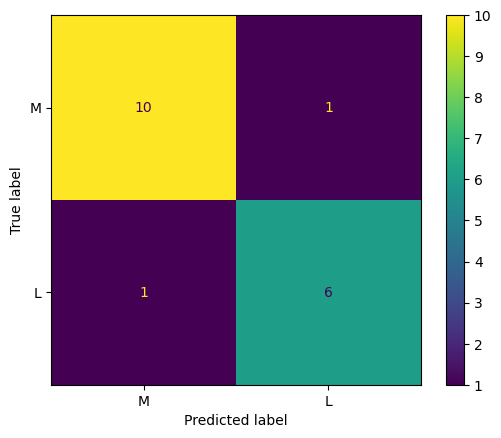

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['M','L'])
cm_display.plot()
plt.show()

In [49]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print("TN:",TN)
print("FP:",FP)
print("FN:",FN)
print("TP:",TP)

TN: 10
FP: 1
FN: 1
TP: 6


In [50]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y,prediction))

Accuracy Score: 0.8888888888888888


In [51]:
from sklearn.metrics import accuracy_score
print("Error Rate:",1-accuracy_score(y,prediction))

Error Rate: 0.11111111111111116


In [54]:
from sklearn.metrics import recall_score
print("Sensitivity:",recall_score(y,prediction,pos_label='M'))
print("Specificity:",recall_score(y,prediction,pos_label='L'))

Sensitivity: 0.8571428571428571
Specificity: 0.9090909090909091


In [55]:
from sklearn.metrics import precision_score
print("Precision Score(for positive):",precision_score(y,prediction,pos_label='M'))
print("Precision Score(for negative):",precision_score(y,prediction,pos_label='L'))

Precision Score(for positive): 0.8571428571428571
Precision Score(for negative): 0.9090909090909091


In [72]:
import pandas as pd
df=pd.read_csv('aptitudecommunication.csv')
df

,Name,Aptitude,Communication,Class
0,Karuna,2,5.0,Speaker
1,Bhuvan,2,6.0,Speaker
2,Gaurav,7,6.0,Leader
3,Parul,7,2.5,Speaker
4,dinesh,8,6.0,Intel
5,Jani,4,7.0,Speaker
6,Bobby,5,3.0,Intel
7,Parimal,3,5.5,Leader
8,Govind,8,3.0,Intel
9,Shushant,6,5.5,Speaker


In [73]:
x=df.iloc[:,1:3]
y=df['Class']
print(x.shape)
print(y.shape)

(14, 2)
(14,)


In [74]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=5)
model=nn.fit(x,y)
prediction=model.predict(x)
print(prediction)

['Speaker' 'Speaker' 'Intel' 'Intel' 'Leader' 'Speaker' 'Intel' 'Speaker'
 'Intel' 'Intel' 'Intel' 'Leader' 'Intel' 'Leader']


In [75]:
diff=pd.DataFrame({'Actual':y,'predicted':prediction})
diff

,Actual,predicted
0,Speaker,Speaker
1,Speaker,Speaker
2,Leader,Intel
3,Speaker,Intel
4,Intel,Leader
5,Speaker,Speaker
6,Intel,Intel
7,Leader,Speaker
8,Intel,Intel
9,Speaker,Intel


In [76]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)

[[4 1 0]
 [1 2 1]
 [2 0 3]]


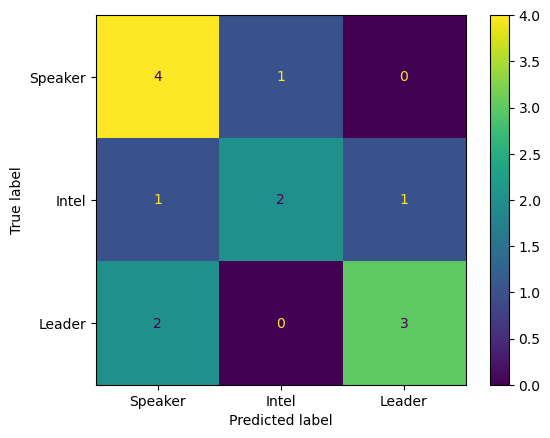

In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Speaker','Intel','Leader'])
cm_display.plot()
plt.show()

In [78]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y,prediction))

Accuracy Score: 0.6428571428571429


In [79]:
import pandas as pd
df=pd.read_csv('AptitudeCommunication (1).csv')
df


,Name,Aptitude,Communication,Class
0,Karuna,2,5.0,Speaker
1,Bhavan,2,6.0,Speaker
2,Gaurav,7,6.0,Leader
3,Parul,7,2.5,Intel
4,Dinesh,8,6.0,Leader
5,Jani,4,7.0,Speaker
6,Bobby,5,3.0,Intel
7,Parimal,3,5.5,Speaker
8,Govind,8,3.0,Intel
9,Sushant,6,5.5,Leader


In [80]:
x=df.iloc[:,1:3]
y=df['Class']
print(x.shape)
print(y.shape)

(14, 2)
(14,)


In [81]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=5)
model=nn.fit(x,y)
prediction=model.predict(x)
print(prediction)

['Speaker' 'Speaker' 'Leader' 'Intel' 'Leader' 'Speaker' 'Intel' 'Speaker'
 'Intel' 'Leader' 'Intel' 'Leader' 'Intel' 'Leader']


In [82]:
diff=pd.DataFrame({'Actual':y,'predicted':prediction})
diff

,Actual,predicted
0,Speaker,Speaker
1,Speaker,Speaker
2,Leader,Leader
3,Intel,Intel
4,Leader,Leader
5,Speaker,Speaker
6,Intel,Intel
7,Speaker,Speaker
8,Intel,Intel
9,Leader,Leader


In [83]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)

[[5 0 0]
 [0 5 0]
 [0 0 4]]


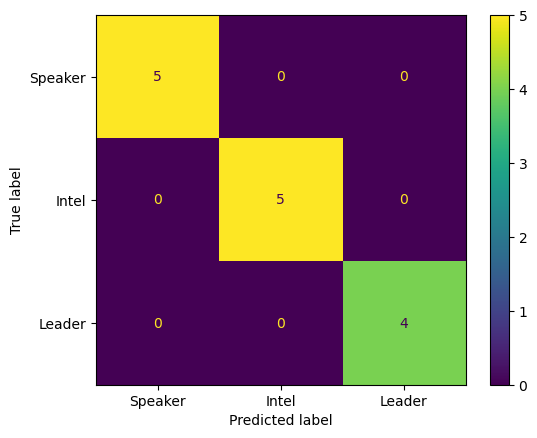

In [84]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Speaker','Intel','Leader'])
cm_display.plot()
plt.show()

In [85]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y,prediction))

Accuracy Score: 1.0


In [ ]:
# 22/4/2026

### Decision Tree

- Entropy
- Information Gain

In [2]:
import pandas as pd
df=pd.read_csv('DecisionTree_Sports.csv')
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,Sunny,Hot,High,Weak,No
1,Day 2,Sunny,Hot,High,Strong,No
2,Day 3,Cloudy,Hot,High,Weak,Yes
3,Day 4,Rain,Mild,High,Weak,Yes
4,Day 5,Rain,Cool,Normal,Weak,Yes
5,Day 6,Rain,Cool,Normal,Strong,No
6,Day 7,Cloudy,Cool,Normal,Strong,Yes
7,Day 8,Sunny,Mild,High,Weak,No
8,Day 9,Sunny,Cool,Normal,Weak,Yes
9,Day 10,Rain,Mild,Normal,Weak,Yes


In [7]:
df['Weather']=df['Weather'].replace('Sunny',2)
df['Weather']=df['Weather'].replace('Cloudy',1)
df['Weather']=df['Weather'].replace('Rain',0)
df['Temperature']=df['Temperature'].replace('Hot',2)
df['Temperature']=df['Temperature'].replace('Mild',1)
df['Temperature']=df['Temperature'].replace('Cool',0)
df['Humidity']=df['Humidity'].replace('High',1)
df['Humidity']=df['Humidity'].replace('Normal',0)
df['Wind']=df['Wind'].replace('Weak',0)
df['Wind']=df['Wind'].replace('Strong',1)
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,2,1,0,No
1,Day 2,2,2,1,1,No
2,Day 3,1,2,1,0,Yes
3,Day 4,0,1,1,0,Yes
4,Day 5,0,0,0,0,Yes
5,Day 6,0,0,0,1,No
6,Day 7,1,0,0,1,Yes
7,Day 8,2,1,1,0,No
8,Day 9,2,0,0,0,Yes
9,Day 10,0,1,0,0,Yes


In [8]:
df.drop('Day',axis=1,inplace=True)
df

,Weather,Temperature,Humidity,Wind,Play_Sports?
0,2,2,1,0,No
1,2,2,1,1,No
2,1,2,1,0,Yes
3,0,1,1,0,Yes
4,0,0,0,0,Yes
5,0,0,0,1,No
6,1,0,0,1,Yes
7,2,1,1,0,No
8,2,0,0,0,Yes
9,0,1,0,0,Yes


In [9]:
x=df.iloc[:,0:4]
y=df.iloc[:,-1]
print(x.shape)
print(y.shape)

(14, 4)
(14,)


In [19]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion='entropy')
model=dtree.fit(x,y)
prediction=model.predict(x)
print(prediction)

['No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes'
 'No']


In [11]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion='gini')    #default value of criterion
model=dtree.fit(x,y)
prediction=model.predict(x)
print(prediction)

['No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes'
 'No']


In [20]:
dtree.get_depth()

4

In [21]:
from sklearn import tree
text_representation=tree.export_text(dtree,feature_names=['Weather','Temperature','Humidity','Wind'])
print(text_representation)

|--- Humidity <= 0.50
|   |--- Weather <= 0.50
|   |   |--- Wind <= 0.50
|   |   |   |--- class: Yes
|   |   |--- Wind >  0.50
|   |   |   |--- class: No
|   |--- Weather >  0.50
|   |   |--- class: Yes
|--- Humidity >  0.50
|   |--- Weather <= 1.50
|   |   |--- Wind <= 0.50
|   |   |   |--- class: Yes
|   |   |--- Wind >  0.50
|   |   |   |--- Weather <= 0.50
|   |   |   |   |--- class: No
|   |   |   |--- Weather >  0.50
|   |   |   |   |--- class: Yes
|   |--- Weather >  1.50
|   |   |--- class: No



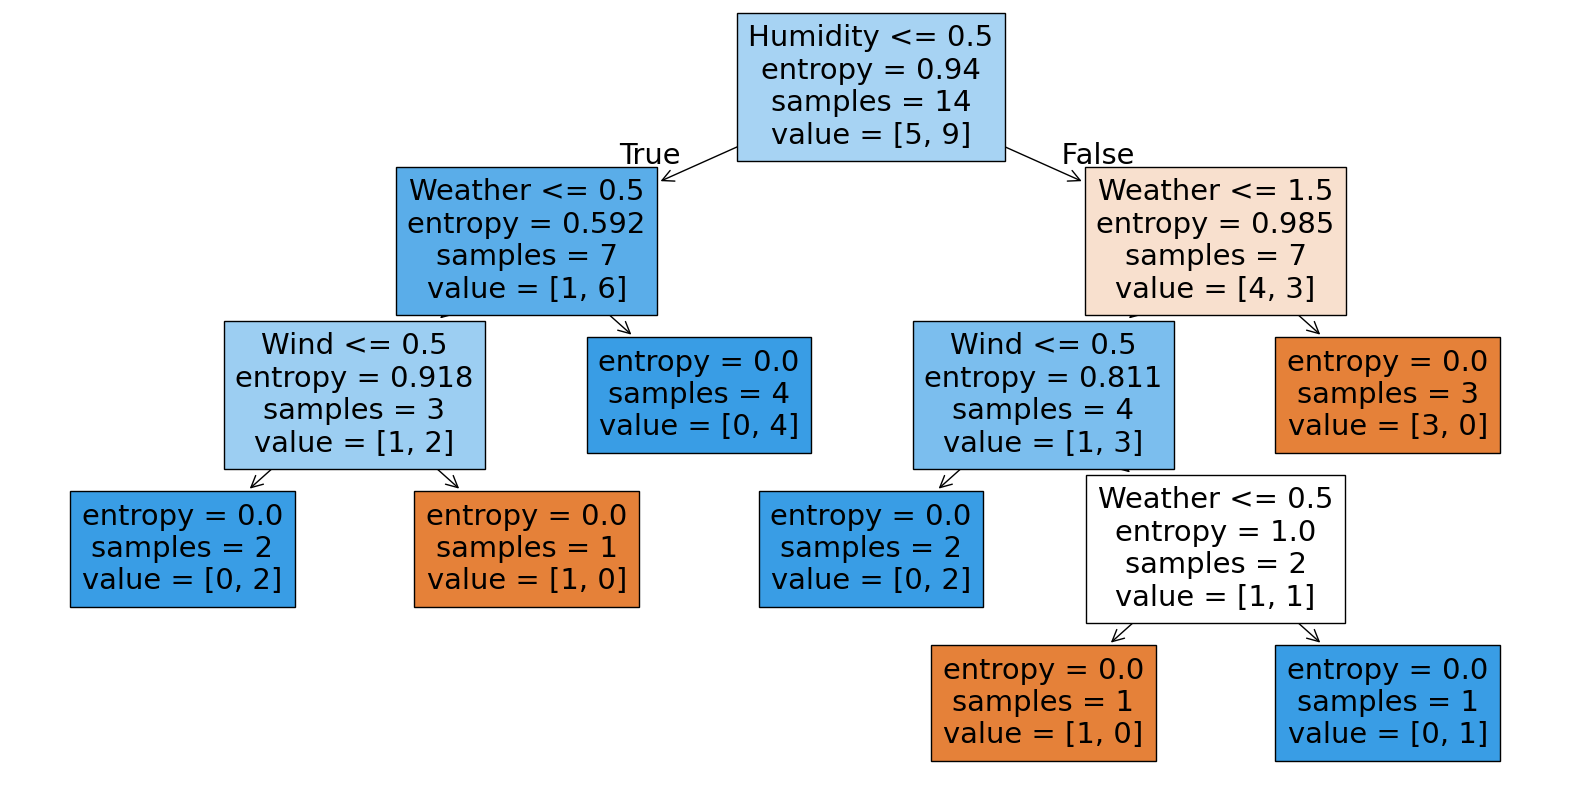

In [22]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dtree,feature_names=list(x.columns),filled=True)
plt.show()